<a href="https://colab.research.google.com/github/tifli/142a-project/blob/main/IOER_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Import Packages

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, cross_val_score, KFold, LeaveOneOut
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
K_FOLDS = 5
RANDOM_STATE = 42
TEST_SIZE = 0.2

##Import Dataset

In [ ]:
url = "https://raw.githubusercontent.com/tifli/142a-project/refs/heads/main/university_ranking.csv"
df = pd.read_csv(url)
df = df[df['year'] >= 2016]

# List of columns that should be numeric but might contain commas or percent signs
cols_to_clean = ['No. of FTE students', 'No. of students per staff',
                 'International students', 'International Outlook', 'Industry']

for col in cols_to_clean:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.replace('%', '').str.replace('-', ''), errors='coerce')

X = df.drop(['Female:Male ratio', 'rank_prefix', 'Industry'], axis=1)
y = df['Industry']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

# Drop NaNs if any were created in the target variable
train_data = train_data.dropna(subset=['Industry'])
test_data = test_data.dropna(subset=['Industry'])

##Define Functions for Model Evaluations

In [ ]:
def VIF(df, columns):
    values = sm.add_constant(df[columns]).values
    num_columns = len(columns)+1
    vif = [variance_inflation_factor(values, i) for i in range(num_columns)]
    return pd.Series(vif[1:], index=columns)

In [ ]:
# compute out-of-sample R-squared using the test set
def OSR2(model, df_train, df_test, dependent_var):
    y_test = df_test[dependent_var]
    y_pred = model.predict(df_test)
    SSE = np.sum((y_test - y_pred)**2)
    SST = np.sum((y_test - np.mean(df_train[dependent_var]))**2)
    return 1 - SSE/SST

In [ ]:
# compute out-of-sample R-squared using the test set
def OSR2_alt(model, df_train, df_test, category_var, dependent_var, features):

    # Use drop_first=False to generate all dummies, then align to model columns
    # This prevents dropping a category that might be the reference in the test
    # set but not the train set
    df_test_encoded = pd.get_dummies(
        df_test[features],
        columns=[category_var],
        drop_first=False,
        dtype=float
    )

    df_test_encoded = sm.add_constant(df_test_encoded)

    # Align columns with the training data features (model parameters)
    # This adds missing columns (filled with 0) and removes extra ones
    df_test_encoded = df_test_encoded.reindex(columns=model.params.index,
                                              fill_value=0)

    y_test = df_test[dependent_var]
    y_pred = model.predict(df_test_encoded)
    SSE = np.sum((y_test - y_pred)**2)
    SST = np.sum((y_test - np.mean(df_train[dependent_var]))**2)
    return 1 - SSE/SST

##Linear Regression

####Without "Name" column

In [ ]:
ols = smf.ols(formula='Industry ~ Rank + Q("No. of FTE students") + Q("No. of students per staff") + Q("International students") + Overall + Teaching + Q("Research Environment") + Q("Research Quality") + Q("International Outlook")',
                 data=train_data)
model1 = ols.fit()
print(model1.summary())

osr_reduced = OSR2(model1, train_data, test_data, 'Industry')
print(f"OSR-squared (reduced model): {osr_reduced}")

                            OLS Regression Results                            
Dep. Variable:               Industry   R-squared:                       0.943
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     3105.
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        07:48:41   Log-Likelihood:                -5277.3
No. Observations:                1696   AIC:                         1.057e+04
Df Residuals:                    1686   BIC:                         1.063e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

####With "Name" column

*Use one-hot encoding*

In [ ]:
features = ['Name', 'Rank', 'No. of FTE students', 'No. of students per staff',
            'International students','Overall', 'Teaching',
            'Research Environment', 'Research Quality', 'International Outlook']
category_var = 'Name'

train_data_encode = pd.get_dummies(
    train_data[features],
    columns=[category_var],
    drop_first=True,
    dtype=float
)

train_data_encode = sm.add_constant(train_data_encode)

depend = train_data['Industry']
model_encode = sm.OLS(depend, train_data_encode).fit()
print(model_encode.summary())

osr_full = OSR2_alt(model_encode, train_data, test_data, category_var, 'Industry', features)
print(f"OSR-squared (full model): {osr_full}")

                            OLS Regression Results                            
Dep. Variable:               Industry   R-squared:                       0.970
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     174.9
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        07:48:42   Log-Likelihood:                -4732.5
No. Observations:                1696   AIC:                             9997.
Df Residuals:                    1430   BIC:                         1.144e+04
Df Model:                         265                                         
Covariance Type:            nonrobust                                         
                                                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

**Summary**

Note that the difference in R-squared and OSR-squared values between the two models above (with and without "Name") is small. In other words, the *reduced* model performs roughly the same as the full model, so dropping the feature "Name" will be helpful since it simplifies the model without losing significant predictive power.

##Feature Selection

*Note: Scaled data for later use*

In [ ]:
from sklearn.preprocessing import StandardScaler

X_train = X_train.drop('Name', axis=1)
X_test = X_test.drop('Name', axis=1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

features.remove('Name')
VIF(train_data, features)

,0
Rank,6.574142
No. of FTE students,1.178331
No. of students per staff,1.369456
International students,2.938679
Overall,277.704653
Teaching,63.562737
Research Environment,78.064922
Research Quality,27.263775
International Outlook,8.140516


In [ ]:
# Remove 'Overall' because of its high VIF
ols = smf.ols(formula='Industry ~ Rank + Q("No. of FTE students") + Q("No. of students per staff") + Q("International students") + Teaching + Q("Research Environment") + Q("Research Quality") + Q("International Outlook")',
                 data=train_data)
model2 = ols.fit()
print(model2.summary())

osr_reduced_overall = OSR2(model2, train_data, test_data, 'Industry')
print(f"OSR-squared (no Overall): {osr_reduced_overall}")

                            OLS Regression Results                            
Dep. Variable:               Industry   R-squared:                       0.173
Model:                            OLS   Adj. R-squared:                  0.169
Method:                 Least Squares   F-statistic:                     43.97
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           2.20e-64
Time:                        07:48:42   Log-Likelihood:                -7547.4
No. Observations:                1696   AIC:                         1.511e+04
Df Residuals:                    1687   BIC:                         1.516e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

**Note**

Because the R-squared value dropped significantly, we shouldn't remove the feature 'Overall'

In [ ]:
# Remove 'Research Environment', the second highest VIF

ols = smf.ols(formula='Industry ~ Rank + Q("No. of FTE students") + Q("No. of students per staff") + Q("International students") + Overall + Teaching + Q("Research Quality") + Q("International Outlook")',
                 data=train_data)
model3 = ols.fit()
print(model3.summary())

osr_reduced_RE = OSR2(model3, train_data, test_data, 'Industry')
print(f"OSR-squared (no Research Environment): {osr_reduced_RE}")

                            OLS Regression Results                            
Dep. Variable:               Industry   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.332
Method:                 Least Squares   F-statistic:                     106.1
Date:                Sun, 19 Apr 2026   Prob (F-statistic):          1.72e-143
Time:                        07:48:42   Log-Likelihood:                -7362.3
No. Observations:                1696   AIC:                         1.474e+04
Df Residuals:                    1687   BIC:                         1.479e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

**Note**

This R-squared value is still significantly smaller than model1, despite it having the second highest VIF value.

Thus, we must use PCA to combine features that are highly correlated with each. In this case, they are most likely 'Overall', 'Research Environment', and (possibly) 'Teaching'.

##PCA

In [ ]:
from sklearn.decomposition import PCA

# (Similar to lab 8)

# Candidate numbers of principal components (max is the number of features in X_train)
max_components = X_train.shape[1]
component_grid = list(range(1, max_components + 1))

# K-fold CV object (Use KFold instead of StratifiedKFold for continuous targets)
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_scores = {}

for k in component_grid:
    fold_R_sq = []

    for train_idx, val_idx in kf.split(X_train):
        # Split the training data into one training fold and one validation fold
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        # Fit PCA only on the training fold
        pca = PCA(n_components=k)
        X_tr_pca = pca.fit_transform(X_tr)
        X_val_pca = pca.transform(X_val)

        # Fit linear regression on the PCA-transformed training fold
        lr = LinearRegression()
        lr.fit(X_tr_pca, y_tr)

        # Predict on the validation fold
        R = lr.score(X_val_pca, y_val)
        fold_R_sq.append(R)

    # Store the mean CV R-squared for this k
    cv_scores[k] = np.mean(fold_R_sq)
    print(f"k = {k:2d}, fold R^2 = {[round(x, 4) for x in fold_R_sq]}, mean = {cv_scores[k]:.4f}")


k =  1, fold R^2 = [-0.0081, -0.0021, -0.0197, -0.001, -0.008], mean = -0.0078
k =  2, fold R^2 = [-0.0075, 0.0079, 0.0015, 0.0227, 0.015], mean = 0.0079
k =  3, fold R^2 = [-0.0204, 0.0214, 0.0197, 0.0216, 0.0402], mean = 0.0165
k =  4, fold R^2 = [0.0601, 0.0733, 0.0551, 0.0588, 0.0956], mean = 0.0686
k =  5, fold R^2 = [0.1458, 0.1234, 0.1398, 0.1256, 0.1522], mean = 0.1374
k =  6, fold R^2 = [0.1666, 0.1749, 0.168, 0.1286, 0.1373], mean = 0.1551
k =  7, fold R^2 = [0.1479, 0.1827, 0.2012, 0.1394, 0.1687], mean = 0.1680
k =  8, fold R^2 = [0.1495, 0.1835, 0.203, 0.139, 0.1695], mean = 0.1689
k =  9, fold R^2 = [0.4868, 0.4304, 0.4788, 0.3878, 0.3346], mean = 0.4237
k = 10, fold R^2 = [0.9435, 0.9412, 0.9512, 0.9441, 0.9429], mean = 0.9446


In [ ]:
# Choose the best number of components
best_k = max(cv_scores, key=cv_scores.get)
print("\nBest number of principal components:", best_k)
print("Best mean CV R-squared:", cv_scores[best_k])


Best number of principal components: 10
Best mean CV R-squared: 0.9445603559853961


In [ ]:
# Refit on the full training set using best_k
pca_best = PCA(n_components=best_k)
X_train_pca_best = pca_best.fit_transform(X_train)
X_test_pca_best = pca_best.transform(X_test)

lr_best = LinearRegression()
lr_best.fit(X_train_pca_best, y_train)

train_R_sq = lr_best.score(X_train_pca_best, y_train)
test_R_sq = lr_best.score(X_test_pca_best, y_test)

print("\nFinal model results")
print("Train R-squared:", round(train_R_sq, 4))
print("Test R-squared :", round(test_R_sq, 4))


Final model results
Train R-squared: 0.9459
Test R-squared : 0.9424


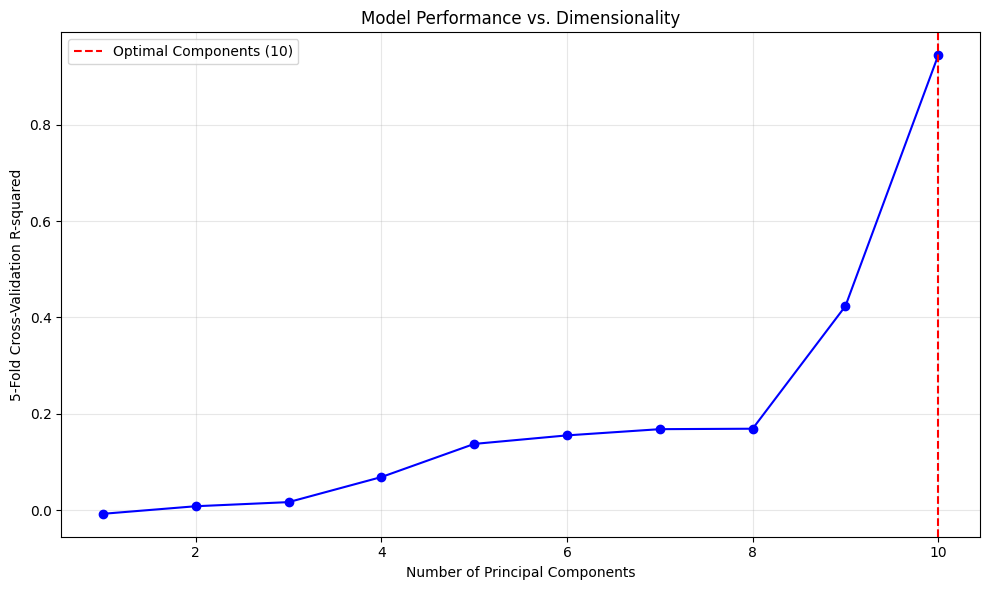

In [ ]:
# --- VISUALIZATION: Cross-Validation R-squared Curve ---
mean_test_scores = [cv_scores[k] for k in component_grid]

plt.figure(figsize=(10, 6))
plt.plot(component_grid, mean_test_scores, marker='o', linestyle='-', color='b')
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Optimal Components ({best_k})')
plt.xlabel('Number of Principal Components')
plt.ylabel(f'5-Fold Cross-Validation R-squared')
plt.title('Model Performance vs. Dimensionality')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()